# CSCI 360 — Lab 0 (Google Colab Guided Walkthrough)

This notebook follows the **Lab 0 PDF** and the supplied Lab 0 Jupyter notebooks. Lab 0 is a warm-up/tutorial and is **not graded**, but its Python/data-science tools are meant to prepare you for later labs.

**How to use this notebook:** run each cell in order, read the output, and then change at least one example yourself. Do not treat this as a file to submit unchanged. The course syllabus allows AI as a learning aid, but requires disclosure/citation of AI-assisted material used in submitted work.

## 0. Colab setup

Because you are using Google Colab, you do **not** need to install Anaconda or configure a local `PATH` just for this lab. Colab already gives you a Python/Jupyter environment.

For the Pandas/plotting sections, upload **`Salaries.csv`** when prompted below. You can get it from the supplied `Lab 0 Data.zip`.

In [1]:
# Core imports used throughout Lab 0
import math
import statistics
import heapq
from collections import deque

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

print("Environment ready")

Environment ready


## 1. Homework submission rules

Lab 0 explicitly tells you to read the detailed homework submission rules on Piazza. The syllabus also says code/simulation results are uploaded to GitHub, while written homework solutions/results must be in PDF format.

For this warm-up, focus on learning the tools. Before later graded work, check Piazza for the exact repository/file naming rules.

# 2. Python Lists

The supplied notebook asks you to practice list creation, adding/removing items, indexing/slicing, list comprehensions, and basic statistics.

### 2.1 Basic list functions

In [2]:
players = ["Federer", "Nadal", "Felix"]

# Append the requested players
players.append("Djokovic")
players.append("Medvedev")
players.append("Sinner")

# Merge another list
new_players = ["Tsitsipas", "Rublev", "Dimitrov"]
players.extend(new_players)

# Remove Medvedev
players.remove("Medvedev")

print(players)

['Federer', 'Nadal', 'Felix', 'Djokovic', 'Sinner', 'Tsitsipas', 'Rublev', 'Dimitrov']


### 2.2 Indexing and slicing

In [3]:
print("Last player:", players[-1])
last_three = players[-3:]
print("Last three:", last_three)

# Extra practice
print("First three:", players[:3])
print("Every other player:", players[::2])
print("Reversed:", players[::-1])

Last player: Dimitrov
Last three: ['Tsitsipas', 'Rublev', 'Dimitrov']
First three: ['Federer', 'Nadal', 'Felix']
Every other player: ['Federer', 'Felix', 'Sinner', 'Rublev']
Reversed: ['Dimitrov', 'Rublev', 'Tsitsipas', 'Sinner', 'Djokovic', 'Felix', 'Nadal', 'Federer']


### 2.3 List comprehensions

In [4]:
# Odd numbers between 50 and 100, squared
odd_squares = [x**2 for x in range(50, 101) if x % 2 == 1]
print("Odd squares:", odd_squares)

# Names containing the vowel 'e' (case-insensitive)
filtered_players = [name for name in players if "e" in name.lower()]
print("Players containing e:", filtered_players)

Odd squares: [2601, 2809, 3025, 3249, 3481, 3721, 3969, 4225, 4489, 4761, 5041, 5329, 5625, 5929, 6241, 6561, 6889, 7225, 7569, 7921, 8281, 8649, 9025, 9409, 9801]
Players containing e: ['Federer', 'Felix', 'Sinner', 'Rublev']


### 2.4 Sorting and statistics

In [5]:
numbers = [1, 37, 2, 59, 46, 32, 12, 40, 78]

numbers_desc = numbers.copy()
numbers_desc.sort(reverse=True)
print("Descending:", numbers_desc)

print("Sum:", sum(numbers))
print("Min:", min(numbers))
print("Max:", max(numbers))
print("Mean:", statistics.mean(numbers))
print("Median:", statistics.median(numbers))

Descending: [78, 59, 46, 40, 37, 32, 12, 2, 1]
Sum: 307
Min: 1
Max: 78
Mean: 34.111111111111114
Median: 37


# 3. Queues

For these exercises, `collections.deque` is convenient because appending to the back and removing from the front are both efficient.

### 3.1 Reorganize contiguous positive values

In [6]:
q = deque([2, -1, 3, 4, -1, 5, 6, 7, -1, 8, 9, 10, -1, -1])

def reOrg(queue):
    """Consume a queue and return groups of contiguous positive values."""
    queue = deque(queue)  # copy so the caller's queue is not destroyed
    result = []
    current = []

    while queue:
        value = queue.popleft()

        if value > 0:
            current.append(value)
        else:
            if current:
                result.append(current)
                current = []

    # In case the queue ends with positive values
    if current:
        result.append(current)

    return result

answer = reOrg(q)
print(answer)
assert answer == [[2], [3, 4], [5, 6, 7], [8, 9, 10]]

[[2], [3, 4], [5, 6, 7], [8, 9, 10]]


### 3.2 Implement a stack using a queue

In [7]:
class MyStack:
    """LIFO stack implemented using one FIFO queue."""
    def __init__(self):
        self.q = deque()

    def push(self, x):
        self.q.append(x)
        # Rotate older elements behind the new element.
        for _ in range(len(self.q) - 1):
            self.q.append(self.q.popleft())

    def pop(self):
        return self.q.popleft()

    def top(self):
        return self.q[0]

    def empty(self):
        return len(self.q) == 0

# Quick check
stack = MyStack()
stack.push(1)
stack.push(2)
print("Top:", stack.top())  # 2
print("Pop:", stack.pop())  # 2
print("Empty?", stack.empty())

Top: 2
Pop: 2
Empty? False


# 4. Dictionaries

### 4.1 Add, remove, and modify key/value pairs

In [8]:
people = {
    "John": "Cena",
    "Jack": "Ma",
    "Jill": "Goodacre"
}

people["Jennifer"] = "Aniston"
del people["Jill"]
people["Jennifer"] = "Lawrence"

print(people)

{'John': 'Cena', 'Jack': 'Ma', 'Jennifer': 'Lawrence'}


### 4.2 Dictionary of lists

In [9]:
# Missing course scores are simply omitted from each student's list.
student_scores = {
    1001: [95, 93, 81, 90, 100],
    1002: [100, 95, 89, 87],
    1003: [92, 91, 80]
}

print("Full dictionary:", student_scores)
print("Student IDs:", list(student_scores.keys()))
print("Scores for 1003:", student_scores[1003])

# Delete all scores for student 1001 while keeping the student ID.
student_scores[1001] = []
print("After clearing 1001's scores:", student_scores)

Full dictionary: {1001: [95, 93, 81, 90, 100], 1002: [100, 95, 89, 87], 1003: [92, 91, 80]}
Student IDs: [1001, 1002, 1003]
Scores for 1003: [92, 91, 80]
After clearing 1001's scores: {1001: [], 1002: [100, 95, 89, 87], 1003: [92, 91, 80]}


### 4.3 Nested list values in a dictionary

In [10]:
patient = {
    'bmi': 30,
    'diagnosis': ['Schizophrenia', 'Diabetes', 'Anxiety'],
    'heart_rates': [95, 123, 135, 91, 175, 2000]
}

patient['medication'] = ['Aripiprazole', 'Citalopram', 'Ibuprofen']
patient['heart_rates'].sort()
patient['heart_rates'].remove(2000)
patient['bmi'] += 5

print(patient)

{'bmi': 35, 'diagnosis': ['Schizophrenia', 'Diabetes', 'Anxiety'], 'heart_rates': [91, 95, 123, 135, 175], 'medication': ['Aripiprazole', 'Citalopram', 'Ibuprofen']}


# 5. Heaps

### 5.1 Min heap

In [11]:
values = [22, 37, 90, 49, 56, 65]
min_heap = values.copy()
heapq.heapify(min_heap)
print("Heapified:", min_heap)

for value in [12, 40, 99]:
    heapq.heappush(min_heap, value)

print("After pushes:", min_heap)
print("Four smallest popped:")
for _ in range(4):
    print(heapq.heappop(min_heap))

Heapified: [22, 37, 65, 49, 56, 90]
After pushes: [12, 37, 22, 40, 56, 90, 65, 49, 99]
Four smallest popped:
12
22
37
40


### 5.2 Max heap using negated numbers

In [12]:
values = [22, 37, 90, 49, 56, 65]
max_heap = [-x for x in values]
heapq.heapify(max_heap)

for value in [12, 40, 99]:
    heapq.heappush(max_heap, -value)

print("Four largest popped:")
for _ in range(4):
    print(-heapq.heappop(max_heap))

Four largest popped:
99
90
65
56


### 5.3 Heap sort

In [13]:
def heap_sort(values):
    h = values.copy()
    heapq.heapify(h)
    return [heapq.heappop(h) for _ in range(len(h))]

values = [22, 37, 90, 49, 56, 65]
print(heap_sort(values))

[22, 37, 49, 56, 65, 90]


# 6. Pandas with `Salaries.csv`

The lab asks you to:
1. make `playerID` the index,
2. use the first row as the header,
3. **skip the second row of the CSV file**.

In Pandas, `skiprows=[1]` skips physical row 2 because row numbering here is zero-based after the header row is counted as row 0.

### 6.1 Upload `Salaries.csv` to Colab

In [14]:
# Run this in Google Colab, then select Salaries.csv.
from google.colab import files
uploaded = files.upload()

# If you selected Salaries.csv, this sets the file name automatically.
csv_name = next(name for name in uploaded if name.lower().endswith('.csv'))
print("Using:", csv_name)

Saving Salaries.csv to Salaries.csv
Using: Salaries.csv


### 6.2 Read the CSV exactly as requested

In [15]:
df = pd.read_csv(
    csv_name,
    header=0,
    index_col='playerID',
    skiprows=[1]
)

display(df.head())
print("Shape:", df.shape)
print("Columns:", list(df.columns))

,yearID,teamID,lgID,salary
playerID,,,,
bedrost01,1985,ATL,NL,550000
benedbr01,1985,ATL,NL,545000
campri01,1985,ATL,NL,633333
ceronri01,1985,ATL,NL,625000
chambch01,1985,ATL,NL,800000


Shape: (25574, 4)
Columns: ['yearID', 'teamID', 'lgID', 'salary']


### 6.3 ATL/HOU players with salary > $1,000,000

In [16]:
high_salary = df[
    (df['teamID'].isin(['ATL', 'HOU'])) &
    (df['salary'] > 1_000_000)
]

print("Matching player IDs:")
print(high_salary.index.tolist())
print("Number of matching rows:", len(high_salary))

Matching player IDs:
['hornebo01', 'murphda05', 'suttebr01', 'ryanno01', 'hornebo01', 'murphda05', 'suttebr01', 'ryanno01', 'griffke01', 'murphda05', 'suttebr01', 'ryanno01', 'murphda05', 'suttebr01', 'smithda02', 'murphda05', 'suttebr01', 'clancji01', 'davisgl01', 'ramirra01', 'scottmi03', 'smithda02', 'esaskni01', 'murphda05', 'smithlo01', 'suttebr01', 'whitter01', 'clancji01', 'darwida01', 'davisgl01', 'deshaji01', 'scottmi03', 'smithda02', 'breamsi01', 'esaskni01', 'gantro01', 'leibrch01', 'pendlte01', 'smithlo01', 'caminke01', 'deshaji01', 'ramirra01', 'scottmi03', 'berenju01', 'bielemi01', 'breamsi01', 'esaskni01', 'gantro01', 'glavito02', 'leibrch01', 'nixonot01', 'penaal01', 'pendlte01', 'smithlo01', 'smoltjo01', 'treadje01', 'biggicr01', 'caminke01', 'finlest01', 'jonesdo01', 'portuma01', 'blausje01', 'breamsi01', 'gantro01', 'glavito02', 'justida01', 'maddugr01', 'nixonot01', 'pendlte01', 'sandede02', 'smithpe02', 'smoltjo01', 'biggicr01', 'caminke01', 'drabedo01', 'finlest01

### 6.4 `describe()` for ATL salary

In [17]:
atl_salary_stats = df.loc[df['teamID'] == 'ATL', 'salary'].describe()
print(atl_salary_stats)

print("\nRequested values:")
print("Minimum:", atl_salary_stats['min'])
print("First quartile (25%):", atl_salary_stats['25%'])
print("Median (50%):", atl_salary_stats['50%'])
print("Third quartile (75%):", atl_salary_stats['75%'])
print("Mean:", atl_salary_stats['mean'])
print("Maximum:", atl_salary_stats['max'])
print("Standard deviation:", atl_salary_stats['std'])

count    8.850000e+02
mean     2.207749e+06
std      3.434320e+06
min      6.000000e+04
25%      3.000000e+05
50%      6.000000e+05
75%      2.400000e+06
max      1.606180e+07
Name: salary, dtype: float64

Requested values:
Minimum: 60000.0
First quartile (25%): 300000.0
Median (50%): 600000.0
Third quartile (75%): 2400000.0
Mean: 2207749.190960452
Maximum: 16061802.0
Standard deviation: 3434319.605441606


### 6.5 Build a dictionary using `iterrows()`

In [18]:
data_dict = {column: [] for column in df.columns}

for _, row in df.iterrows():
    for column in df.columns:
        data_dict[column].append(row[column])

print("Dictionary keys:", data_dict.keys())
print("First 3 yearID values:", data_dict['yearID'][:3])
print("First 3 teamID values:", data_dict['teamID'][:3])

Dictionary keys: dict_keys(['yearID', 'teamID', 'lgID', 'salary'])
First 3 yearID values: [1985, 1985, 1985]
First 3 teamID values: ['ATL', 'ATL', 'ATL']


### 6.6 Create a DataFrame from that dictionary and rename headers `a`, `b`, `c`, ...

In [19]:
rebuilt_df = pd.DataFrame(data_dict)
rebuilt_df.columns = [chr(ord('a') + i) for i in range(len(rebuilt_df.columns))]

display(rebuilt_df.head())

,a,b,c,d
0,1985,ATL,NL,550000
1,1985,ATL,NL,545000
2,1985,ATL,NL,633333
3,1985,ATL,NL,625000
4,1985,ATL,NL,800000


# 7. NumPy

### 7.1 Create a 2-D array

In [20]:
list_2d = [
    [1, 2, 3],
    [4, 5, 6],
    [7, 8, 9]
]

arr = np.array(list_2d)
print(arr)

[[1 2 3]
 [4 5 6]
 [7 8 9]]


### 7.2 Inspect ndarray attributes

In [21]:
print("ndim:", arr.ndim)
print("shape:", arr.shape)
print("size:", arr.size)
print("dtype:", arr.dtype)
print("itemsize:", arr.itemsize)
print("data:", arr.data)

ndim: 2
shape: (3, 3)
size: 9
dtype: int64
itemsize: 8
data: <memory at 0x7a80990fb850>


### 7.3 Reshape and flatten

In [22]:
print("Original shape:", arr.shape)
print("Reshaped 1 x 9:\n", arr.reshape(1, 9))
print("Flattened:", arr.flatten())

Original shape: (3, 3)
Reshaped 1 x 9:
 [[1 2 3 4 5 6 7 8 9]]
Flattened: [1 2 3 4 5 6 7 8 9]


### 7.4 Slicing 1-D and 2-D arrays

In [23]:
one_d = np.array([10, 20, 30, 40, 50, 60])
print("1-D slice [1:5:2]:", one_d[1:5:2])

print("2-D arr[1:]:\n", arr[1:])
print("2-D arr[1:, 0:2]:\n", arr[1:, 0:2])

1-D slice [1:5:2]: [20 40]
2-D arr[1:]:
 [[4 5 6]
 [7 8 9]]
2-D arr[1:, 0:2]:
 [[4 5]
 [7 8]]


### 7.5 Common calculations

In [24]:
print("argmin:", arr.argmin())
print("argmax:", arr.argmax())
print("min:", arr.min())
print("max:", arr.max())
print("mean:", arr.mean())
print("sum:", arr.sum())
print("std:", arr.std())
print("dot(arr, arr):\n", np.dot(arr, arr))
print("square:\n", np.square(arr))
print("sqrt:\n", np.sqrt(arr))
print("abs:\n", np.abs(-arr))
print("exp of first row:\n", np.exp(arr[0]))
print("sign of [-3, 0, 4]:", np.sign(np.array([-3, 0, 4])))
print("mod(arr, 2):\n", np.mod(arr, 2))

argmin: 0
argmax: 8
min: 1
max: 9
mean: 5.0
sum: 45
std: 2.581988897471611
dot(arr, arr):
 [[ 30  36  42]
 [ 66  81  96]
 [102 126 150]]
square:
 [[ 1  4  9]
 [16 25 36]
 [49 64 81]]
sqrt:
 [[1.         1.41421356 1.73205081]
 [2.         2.23606798 2.44948974]
 [2.64575131 2.82842712 3.        ]]
abs:
 [[1 2 3]
 [4 5 6]
 [7 8 9]]
exp of first row:
 [ 2.71828183  7.3890561  20.08553692]
sign of [-3, 0, 4]: [-1  0  1]
mod(arr, 2):
 [[1 0 1]
 [0 1 0]
 [1 0 1]]


### 7.6 Useful NumPy constructors

In [25]:
print("arange:", np.arange(0, 10, 2))
print("ones:\n", np.ones((2, 3)))
print("zeros:\n", np.zeros((2, 3)))
print("eye:\n", np.eye(3))
print("linspace:", np.linspace(0, 1, 5))

left = np.array([[1, 2], [3, 4]])
right = np.array([[5, 6]])
print("concatenate rows:\n", np.concatenate((left, right), axis=0))

arange: [0 2 4 6 8]
ones:
 [[1. 1. 1.]
 [1. 1. 1.]]
zeros:
 [[0. 0. 0.]
 [0. 0. 0.]]
eye:
 [[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]
linspace: [0.   0.25 0.5  0.75 1.  ]
concatenate rows:
 [[1 2]
 [3 4]
 [5 6]]


# 8. Scikit-Learn

The Lab 0 handout presents a **reference list** of useful scikit-learn classes rather than a long set of required outputs. The following cells give you a compact import map and a tiny end-to-end example so you know the basic API pattern: `fit(...)`, `predict(...)`, and metrics.

### 8.1 Import map for the tools listed in Lab 0

In [26]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, RepeatedKFold,
    LeaveOneOut, KFold, cross_validate, cross_val_predict, cross_val_score
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression, LogisticRegressionCV, LassoCV, RidgeCV
from sklearn.metrics import accuracy_score, auc, f1_score, hamming_loss, precision_score, recall_score, roc_auc_score
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, AdaBoostClassifier, AdaBoostRegressor
from sklearn.svm import LinearSVC, LinearSVR
from sklearn.multiclass import OneVsOneClassifier, OneVsRestClassifier
from sklearn.cluster import KMeans
from scipy.cluster import hierarchy

print("Lab 0 scikit-learn/scipy imports succeeded")

Lab 0 scikit-learn/scipy imports succeeded


### 8.2 Tiny preprocessing + KNN example

In [27]:
from sklearn.datasets import load_iris

X, y = load_iris(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train_scaled, y_train)
pred = model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 0.9210526315789473


# 9. Matplotlib

### 9.1 Plot a parabola with title/labels/grid

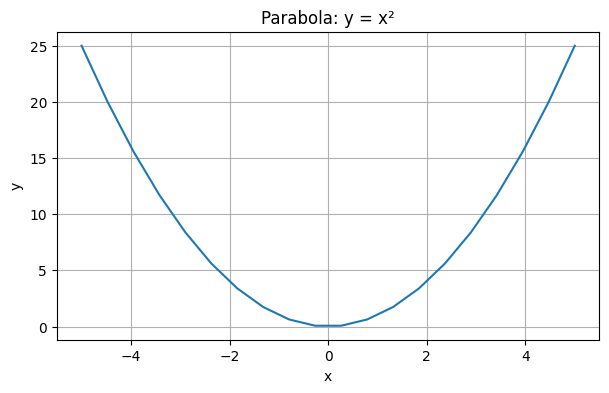

In [28]:
x = np.linspace(-5, 5, num=20)
y = np.array([j ** 2 for j in x])

plt.figure(figsize=(7, 4))
plt.plot(x, y)
plt.title("Parabola: y = x²")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.show()

### 9.2 What if x is not sorted?

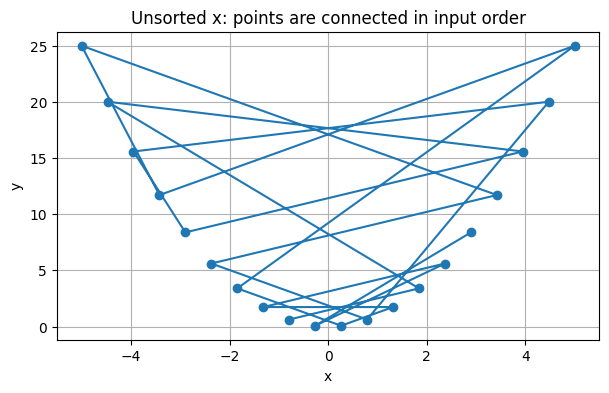

Observation: plt.plot connects points in the order they appear, so unsorted x values create a zig-zagging line.


In [29]:
x_unsorted = np.linspace(-5, 5, num=20)
np.random.default_rng(42).shuffle(x_unsorted)
y_unsorted = np.array([j ** 2 for j in x_unsorted])

plt.figure(figsize=(7, 4))
plt.plot(x_unsorted, y_unsorted, marker='o')
plt.title("Unsorted x: points are connected in input order")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.show()

print("Observation: plt.plot connects points in the order they appear, so unsorted x values create a zig-zagging line.")

### 9.3 Multiple curves, styles, legend, and math text

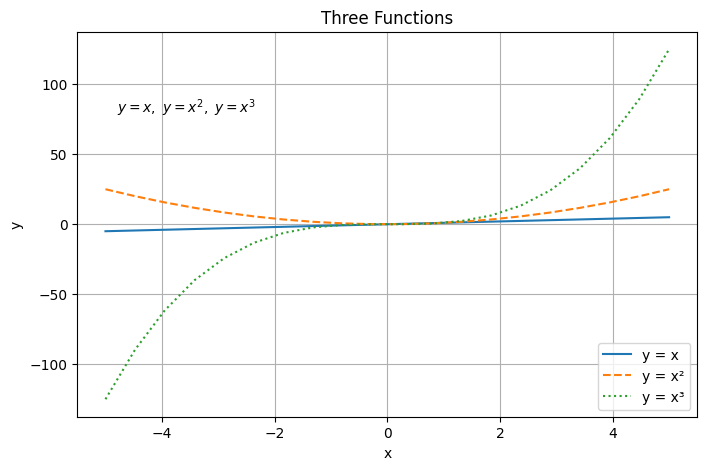

In [30]:
x = np.linspace(-5, 5, num=20)
y1 = x
y2 = x**2
y3 = x**3

plt.figure(figsize=(8, 5))
plt.plot(x, y1, '-', label='y = x')
plt.plot(x, y2, '--', label='y = x²')
plt.plot(x, y3, ':', label='y = x³')
plt.title("Three Functions")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.text(-4.8, 80, r'$y=x,\ y=x^2,\ y=x^3$')
plt.show()

### 9.4 Three curves in one figure (no subplots)

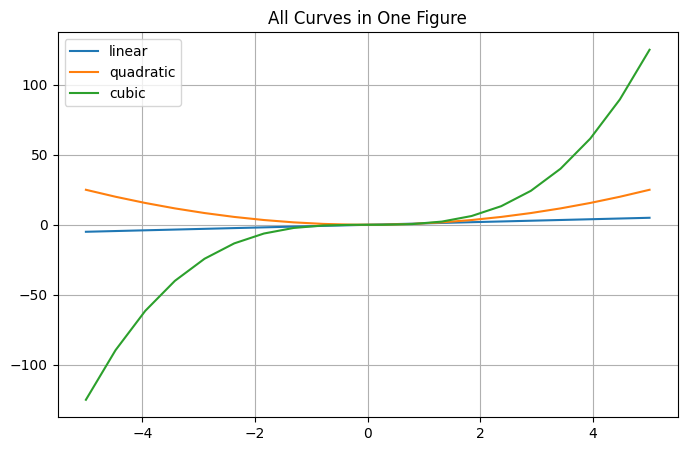

In [31]:
plt.figure(figsize=(8, 5))
plt.plot(x, y1, label='linear')
plt.plot(x, y2, label='quadratic')
plt.plot(x, y3, label='cubic')
plt.title("All Curves in One Figure")
plt.legend()
plt.grid(True)
plt.show()

### 9.5 Multiple subplots, one curve per subplot

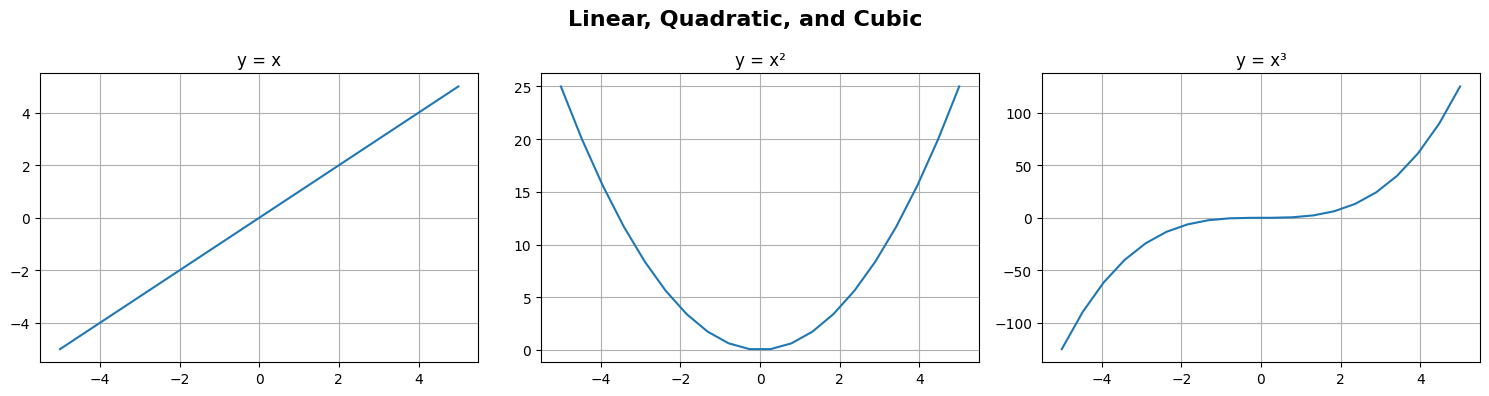

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Linear, Quadratic, and Cubic", fontsize=16, fontweight='bold')

axes[0].plot(x, y1)
axes[0].set_title("y = x")
axes[0].grid(True)

axes[1].plot(x, y2)
axes[1].set_title("y = x²")
axes[1].grid(True)

axes[2].plot(x, y3)
axes[2].set_title("y = x³")
axes[2].grid(True)

plt.tight_layout()
plt.show()

### 9.6 Axis limits and logarithmic scale

The starter uses x values from -5 to 5. A logarithmic **x-axis cannot display negative x values**, so this example keeps the original x values and applies a log scale to y (which is positive for these 20 sampled points).

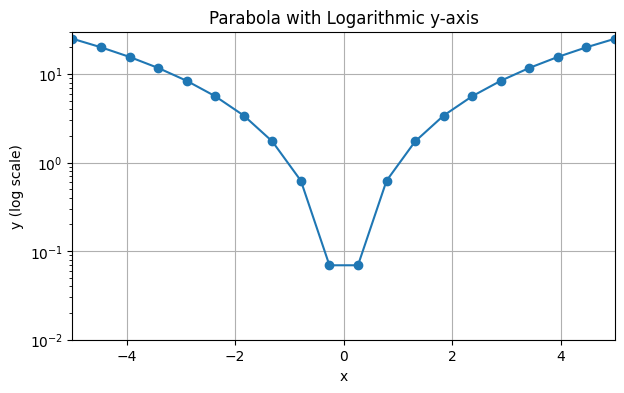

In [33]:
x = np.linspace(-5, 5, num=20)
y = x**2

plt.figure(figsize=(7, 4))
plt.plot(x, y, marker='o')
plt.xlim(-5, 5)
plt.ylim(0.01, 30)
plt.yscale('log')
plt.title("Parabola with Logarithmic y-axis")
plt.xlabel("x")
plt.ylabel("y (log scale)")
plt.grid(True)
plt.show()

# 10. Pandas plotting and Seaborn

### 10.1 ATL: scatter plot of yearID vs salary

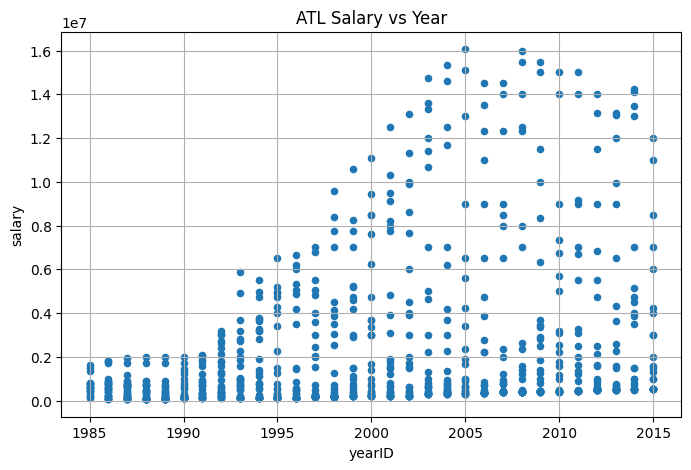

In [34]:
atl = df[df['teamID'] == 'ATL']
atl.plot.scatter(x='yearID', y='salary', figsize=(8, 5), title='ATL Salary vs Year')
plt.grid(True)
plt.show()

### 10.2 Year 1985: average salary by team

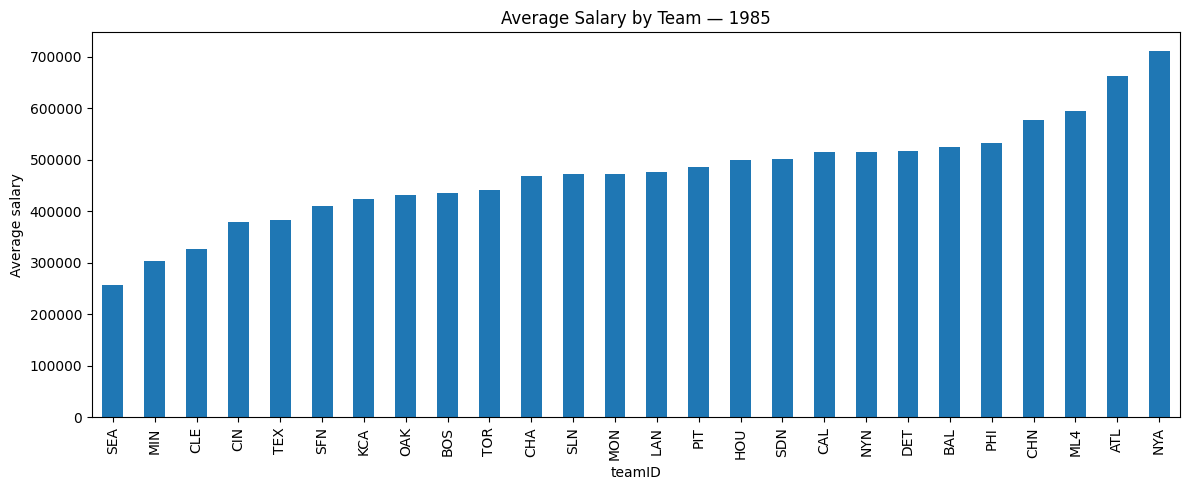

In [35]:
avg_1985 = df[df['yearID'] == 1985].groupby('teamID')['salary'].mean().sort_values()
avg_1985.plot.bar(figsize=(12, 5), title='Average Salary by Team — 1985')
plt.ylabel('Average salary')
plt.tight_layout()
plt.show()

### 10.3 ATL annual average salary

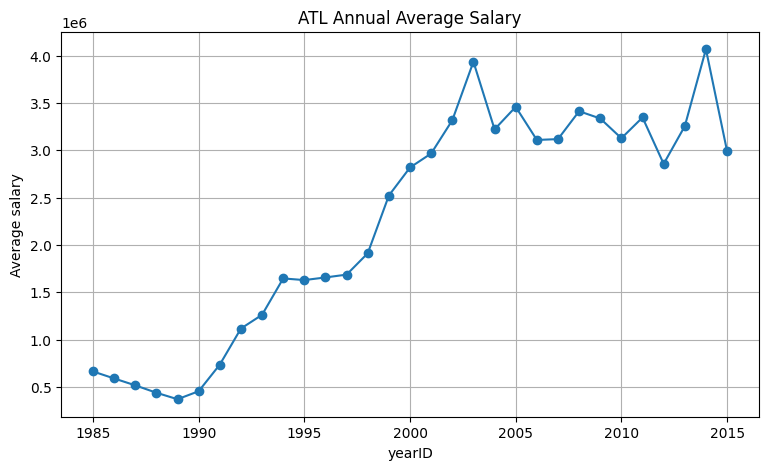

In [36]:
atl_yearly = atl.groupby('yearID')['salary'].mean()
atl_yearly.plot.line(figsize=(9, 5), marker='o', title='ATL Annual Average Salary')
plt.ylabel('Average salary')
plt.grid(True)
plt.show()

### 10.4 Add a random numeric feature and use `pairplot` for ATL

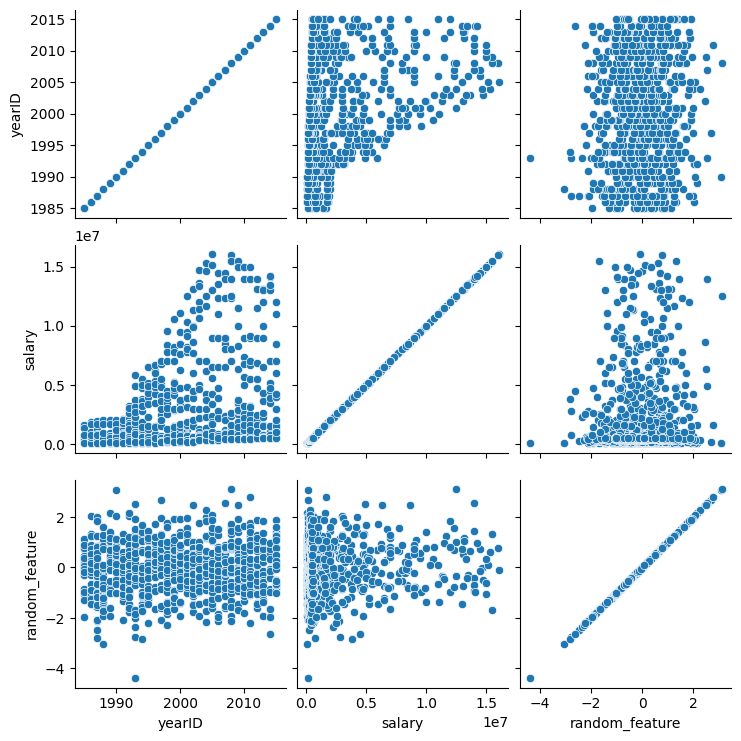

In [37]:
df_plot = df.copy()
rng = np.random.default_rng(42)
df_plot['random_feature'] = rng.normal(size=len(df_plot))

atl_plot = df_plot[df_plot['teamID'] == 'ATL']
sns.pairplot(atl_plot[['yearID', 'salary', 'random_feature']].dropna(), diag_kind=None)
plt.show()

### 10.5 Year 1985: salary distribution by team with a boxplot

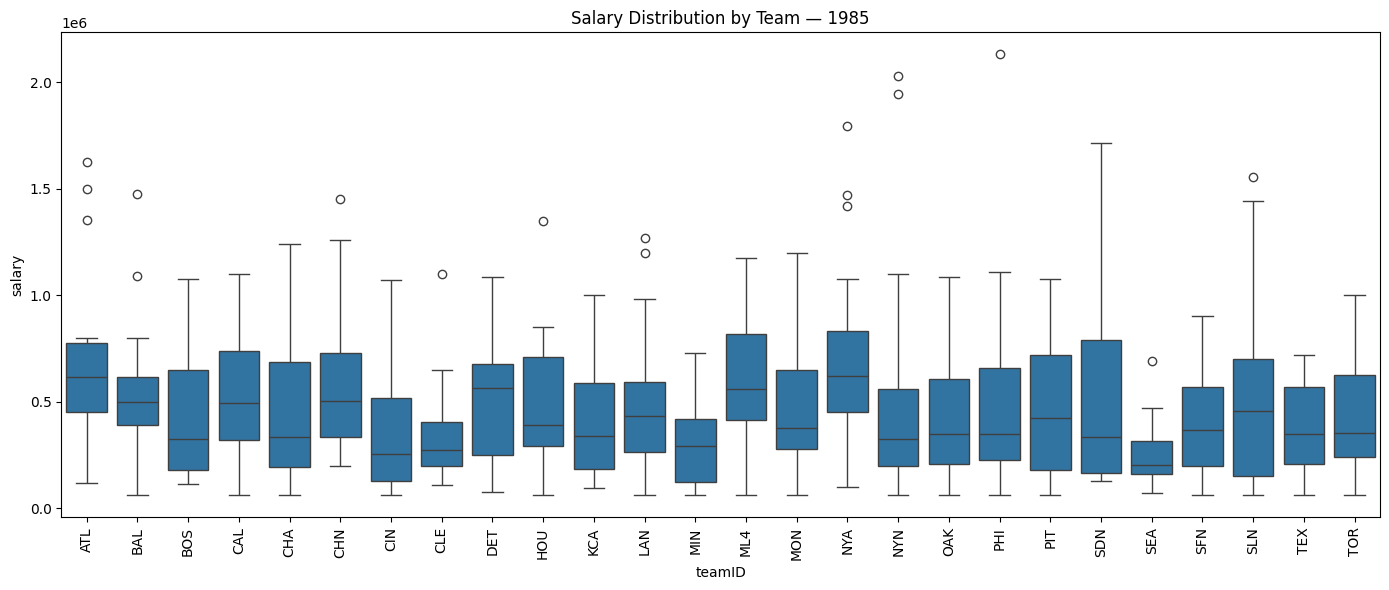

In [38]:
y1985 = df_plot[df_plot['yearID'] == 1985]

plt.figure(figsize=(14, 6))
sns.boxplot(data=y1985, x='teamID', y='salary')
plt.title('Salary Distribution by Team — 1985')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### 10.6 Quick examples of `lmplot`, `catplot`, `relplot`, and `jointplot`

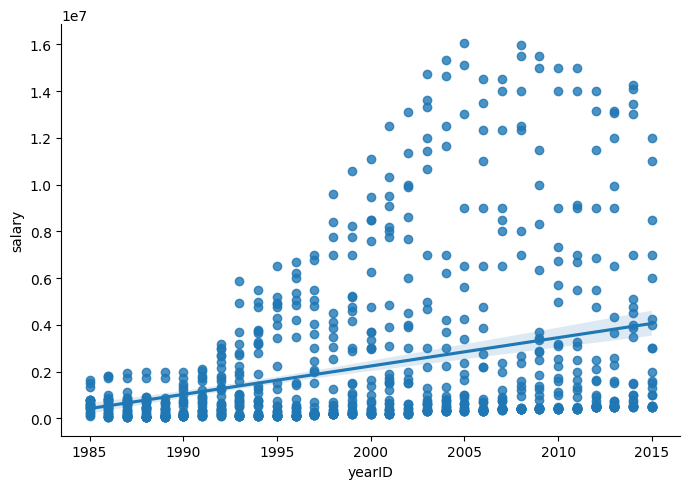

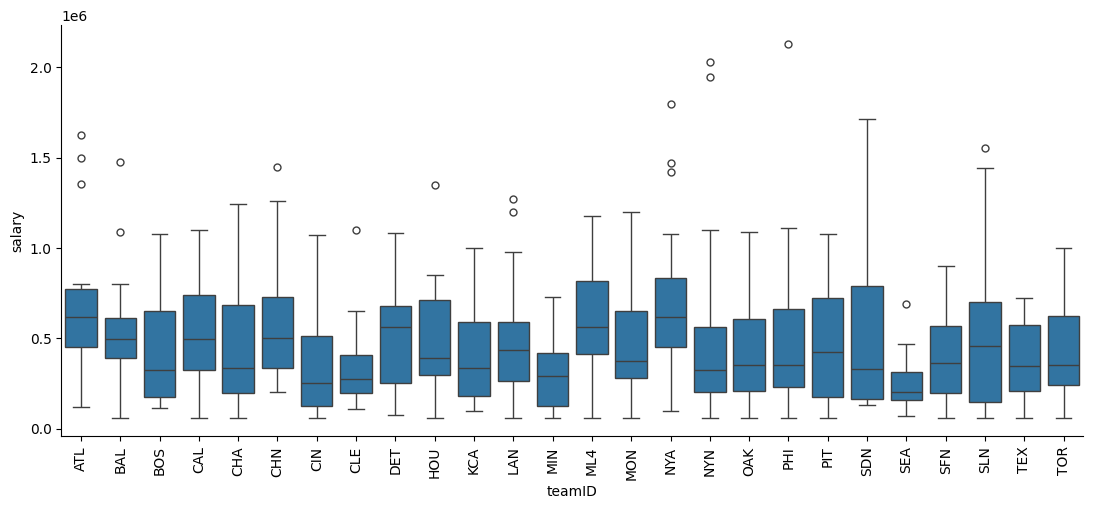

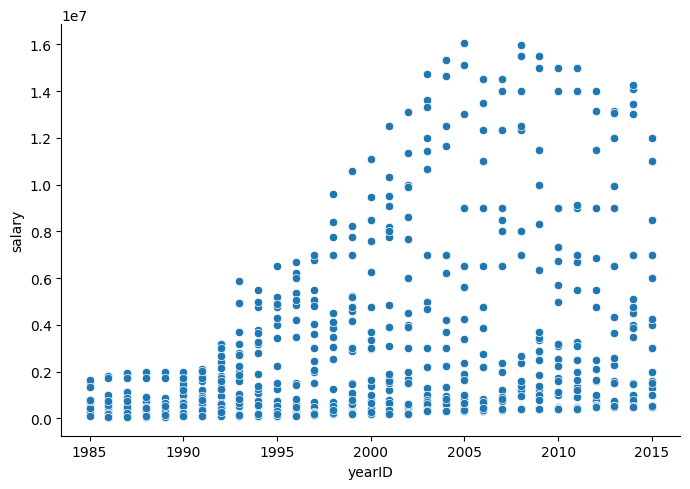

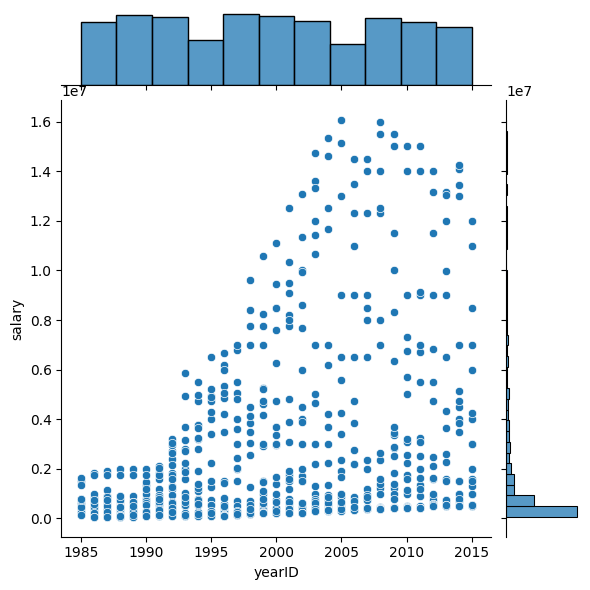

In [39]:
# lmplot: regression-style relationship
sns.lmplot(data=atl_plot, x='yearID', y='salary', height=5, aspect=1.4)
plt.show()

# catplot: categorical summary; use a small year slice for readability
sns.catplot(data=y1985, x='teamID', y='salary', kind='box', height=5, aspect=2.2)
plt.xticks(rotation=90)
plt.show()

# relplot: relationship plot
sns.relplot(data=atl_plot, x='yearID', y='salary', kind='scatter', height=5, aspect=1.4)
plt.show()

# jointplot: joint + marginal distributions
sns.jointplot(data=atl_plot, x='yearID', y='salary', kind='scatter', height=6)
plt.show()

# 11. Jupyter/Colab productivity

The original lab mentions classic Jupyter Notebook extensions and the Pixie debugger. In Colab, many convenience features are already integrated (table of contents, variable inspection, interactive outputs, and browser-based debugging support). You can still explore the original resources if you want experience with local Jupyter.

# 12. Git and GitHub

The lab asks you to practice `git init`, a `dev` branch, commits, merge to the default branch, and pushing to GitHub.

In Colab, shell commands can be run with `!`. The cells below are a safe practice sequence. **Do not paste a GitHub password or access token into a notebook cell.** For actual pushes, use Colab's **File → Save a copy in GitHub** workflow or GitHub authentication that does not expose credentials in the notebook.

In [40]:
# Example local Git practice inside the Colab runtime.
# This runtime is temporary, so use it only for learning the commands.
!mkdir -p /content/csci360_git_practice
%cd /content/csci360_git_practice
!git init
!git config user.email "student@example.com"
!git config user.name "CSCI 360 Student"

/content/csci360_git_practice
hint: Using 'master' as the name for the initial branch. This default branch name
hint: is subject to change. To configure the initial branch name to use in all
hint: of your new repositories, which will suppress this warning, call:
hint: 
hint: 	git config --global init.defaultBranch <name>
hint: 
hint: Names commonly chosen instead of 'master' are 'main', 'trunk' and
hint: 'development'. The just-created branch can be renamed via this command:
hint: 
hint: 	git branch -m <name>
Initialized empty Git repository in /content/csci360_git_practice/.git/


In [41]:
# Create a small file so there is something to commit.
with open("practice.py", "w") as f:
    f.write("print('CSCI 360 Lab 0')\n")

!git add practice.py
!git commit -m "Initial Lab 0 practice commit"
!git checkout -b dev

with open("practice.py", "a") as f:
    f.write("print('Change made on dev')\n")

!git add practice.py
!git commit -m "Update on dev branch"

[master (root-commit) ccd6f87] Initial Lab 0 practice commit
 1 file changed, 1 insertion(+)
 create mode 100644 practice.py
Switched to a new branch 'dev'
[dev 3c12542] Update on dev branch
 1 file changed, 1 insertion(+)


In [42]:
# Merge dev into the default branch.
# A newly initialized repo may use 'master' or 'main', so detect it first.
import subprocess

branches = subprocess.check_output(['git', 'branch', '--format=%(refname:short)'], text=True).split()
default_branch = 'master' if 'master' in branches else 'main'

!git checkout $default_branch
!git merge dev
!git log --oneline --graph --all -5

Switched to branch 'master'
Updating ccd6f87..3c12542
Fast-forward
 practice.py | 1 +
 1 file changed, 1 insertion(+)
* 3c12542 (HEAD -> master, dev) Update on dev branch
* ccd6f87 Initial Lab 0 practice commit
